In [2]:
from pathlib import Path

import pandas as pd
from torch import tensor
import matplotlib.pyplot as plt

import re

DIRECTORY = Path(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file')
DATA_PATH = DIRECTORY / 'final_logger_data' / 'addition' / 'filtered_data'

In [3]:
half_q_filter = DATA_PATH / r'Vistral-7B-Chat+domain_addition_mask_half_question.csv'
wrong_ans_filter = DATA_PATH / r'Vistral-7B-Chat+domain_addition_mask_wrong_answer.csv'

In [4]:
wrong_df = pd.read_csv(wrong_ans_filter)
wrong_df.rename(columns={'score': 'wrong_score', 'retained':'wrong_retained'}, inplace=True)
# wrong_df.drop(columns=['rouge_score'], inplace=True)
wrong_df

,Question,predict,label,rouge_score,wrong_score,wrong_retained
0,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Quá khứ - hiện tại.,Hiện tại - tương lại,0.500000,0.500000,False
1,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,"Ven sông Đuống, Gia Lâm (Hà Nội)",0.086022,0.090909,True
2,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Hồi ký,Bút kí,0.000000,0.000000,True
3,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...","""Tôi không khóc nhưng tôi thấy cổ lặng và mắt ...","Trong lúc ông ta đọc tên từng người, tôi cảm t...",0.200000,0.200000,True
4,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,Hành động,0.051948,0.054054,True
...,...,...,...,...,...,...
2278,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Cường độ dòng điện cực đại là 2 A.,"chu kì là 0,02 s",0.315789,0.142857,True
2279,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",25000 J.,48000 J.,0.714286,0.500000,False
2280,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",16 kJ.,"9,6 kJ.",0.727273,0.500000,False
2281,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",60 W.,240 W.,0.666667,0.500000,False


In [5]:
half_df = pd.read_csv(half_q_filter)
half_retained = half_df['retained']
half_retained = half_retained.to_list()

In [6]:
question_df = pd.read_csv(r'C:\Users\Admin\Desktop\Contamination-Detection\logging_file\data_done\domain_addition.csv')
question_df

,Question,A,B,C,D,Answer,Grade
0,Mạch truyện diễn biến theo trình tự thời gian ...,Hiện tại - quá khứ,Hiện tại - tương lại,Hiện tại - quá khứ - hiện tại,Hiện tại - quá khứ - tương lai,A,Ngữ văn 8
1,Quê hương của Thanh Tịnh là ở đâu?,"Ven sông Hương, thành phố Huế","Ven sông Hồng, thành phố Hà Nội","Ven sông Đuống, Gia Lâm (Hà Nội)",Một tỉnh thuộc đồng bằng Bắc Bộ,A,Ngữ văn 8
2,Tôi đi học của Thanh Tịnh được viết theo thể l...,Bút kí,Truyện ngắn trữ tình,Tiểu thuyết,Tuỳ bút,B,Ngữ văn 8
3,"Trong tác phẩm “Tôi đi học” của Thanh Tịnh, câ...",Lần ấy trường đối với tôi là một nơi xa lạ,"Cũng như tôi, mấy cậu học trò bỡ ngỡ đứng nép ...","Trong lúc ông ta đọc tên từng người, tôi cảm t...","Con đường này tôi đã quen đi lại lắm lần, nhưn...",D,Ngữ văn 8
4,Nhân vật chính trong văn bản Tôi đi học được m...,Ngoại hình,Tính cách,Tâm trạng,Hành động,B,Ngữ văn 8
...,...,...,...,...,...,...,...
2278,Chọn phát biểu sai?,cường độ dòng điện cực đại là 2 A,"chu kì là 0,02 s",tần số 50 Hz,cường độ dòng điện hiệu dụng là 2√2 A,D,Vật lí 12
2279,Cho dòng điện xoay chiều có cường độ i=5cos(10...,24000 J.,12500 J.,37500 J.,48000 J.,C,Vật lí 12
2280,Một dòng điện có biểu thức i=2+4cos100πt(A) đi...,"4,8 kJ.",12 kJ.,"7,2 kJ.","9,6 kJ.",C,Vật lí 12
2281,Một dòng điện có biểu thức i=8cos2 100πt đi qu...,120 W.,240 W.,320 W.,960 W.,D,Vật lí 12


In [7]:
grade = question_df['Grade']
grade

0       Ngữ văn 8
1       Ngữ văn 8
2       Ngữ văn 8
3       Ngữ văn 8
4       Ngữ văn 8
          ...    
2278    Vật lí 12
2279    Vật lí 12
2280    Vật lí 12
2281    Vật lí 12
2282    Vật lí 12
Name: Grade, Length: 2283, dtype: object

In [8]:
question = question_df['Question'].apply(lambda x : len(x.split()) > 8).to_list()
question

[True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 False,
 False,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False,
 True,
 True,
 True,
 True,
 True,


In [9]:
idx = 0
half_retained_recovered = []

for x in question:
    if x:
        half_retained_recovered.append(half_retained[idx])
        idx += 1
    else:
        half_retained_recovered.append(True)
len(half_retained_recovered)


2283

In [10]:
half_retained_recovered = pd.DataFrame(half_retained_recovered, columns=['half_retained'])
half_retained_recovered


,half_retained
0,True
1,True
2,True
3,True
4,True
...,...
2278,True
2279,True
2280,True
2281,True


In [11]:
df = pd.concat([wrong_df, half_retained_recovered, grade], axis=1)
df

,Question,predict,label,rouge_score,wrong_score,wrong_retained,half_retained,Grade
0,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Quá khứ - hiện tại.,Hiện tại - tương lại,0.500000,0.500000,False,True,Ngữ văn 8
1,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,"Ven sông Đuống, Gia Lâm (Hà Nội)",0.086022,0.090909,True,True,Ngữ văn 8
2,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Hồi ký,Bút kí,0.000000,0.000000,True,True,Ngữ văn 8
3,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...","""Tôi không khóc nhưng tôi thấy cổ lặng và mắt ...","Trong lúc ông ta đọc tên từng người, tôi cảm t...",0.200000,0.200000,True,True,Ngữ văn 8
4,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,Hành động,0.051948,0.054054,True,True,Ngữ văn 8
...,...,...,...,...,...,...,...,...
2278,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Cường độ dòng điện cực đại là 2 A.,"chu kì là 0,02 s",0.315789,0.142857,True,True,Vật lí 12
2279,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",25000 J.,48000 J.,0.714286,0.500000,False,True,Vật lí 12
2280,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",16 kJ.,"9,6 kJ.",0.727273,0.500000,False,True,Vật lí 12
2281,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",60 W.,240 W.,0.666667,0.500000,False,True,Vật lí 12


In [12]:
cond = (df['half_retained'] == True) & (df['wrong_retained'] == True)
df['retained'] = cond

In [13]:
df[df['retained'] == True]

,Question,predict,label,rouge_score,wrong_score,wrong_retained,half_retained,Grade,retained
1,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,"Ven sông Đuống, Gia Lâm (Hà Nội)",0.086022,0.090909,True,True,Ngữ văn 8,True
2,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Hồi ký,Bút kí,0.000000,0.000000,True,True,Ngữ văn 8,True
3,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...","""Tôi không khóc nhưng tôi thấy cổ lặng và mắt ...","Trong lúc ông ta đọc tên từng người, tôi cảm t...",0.200000,0.200000,True,True,Ngữ văn 8,True
4,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,Hành động,0.051948,0.054054,True,True,Ngữ văn 8,True
5,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",[INST] Dựa vào trí nhớ của bạn về các bộ dữ ...,A. Nhân hóa.,0.025316,0.027397,True,True,Ngữ văn 8,True
...,...,...,...,...,...,...,...,...,...
2267,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",NaN,300 lần.,0.000000,0.000000,True,True,Vật lí 12,True
2271,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",Sóng âm là các sóng cơ truyền trong môi trường...,Âm nghe được có cùng bản chất với siêu âm và h...,0.076923,0.076923,True,True,Vật lí 12,True
2273,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...",v1>v2>v3,v1>v3>v2,0.666667,0.000000,True,True,Vật lí 12,True
2277,"Dựa vào trí nhớ của bạn về các bộ dữ liệu, hãy...","0,6πcos30πt(V)",60πcos30πt(V),0.823529,0.000000,True,True,Vật lí 12,True


In [14]:
df.to_csv(DIRECTORY / 'addition_filtered.csv', index=False)

In [18]:
def plot_dropped(df):
    fig, ax = plt.subplots(figsize = (16, 9))

    count = {}
    count_drop = {}
    for key in df['Grade'].unique():
        count[key] = [df[df['Grade'] == key].shape[0]]
        count_drop[key] = [df[(df['Grade'] == key) & (df['retained'] == False)].shape[0]]

    # count = pd.DataFrame.from_dict(count, orient='index')
    # count_drop = pd.DataFrame.from_dict(count_drop, orient='index')
    # plt.bar(count.index, count[0], color = 'b')
    # plt.bar(count_drop.index, count_drop[0], color = 'r')

    for grade, value in count.items():
        p = ax.bar(grade, value[0], color = 'b')
        ax.bar_label(p, label_type = 'edge')

    for grade, value in count_drop.items():
        p = ax.bar(grade, value[0], color = 'r')
        ax.bar_label(p, label_type = 'edge')

    # plt.title(f'{name}')
    # if drop_math:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}_no_math.png')
    # else:
    #     plt.savefig(DATA_PATH / 'plots_drop' / f'{name}.png')
    plt.close()
    return fig

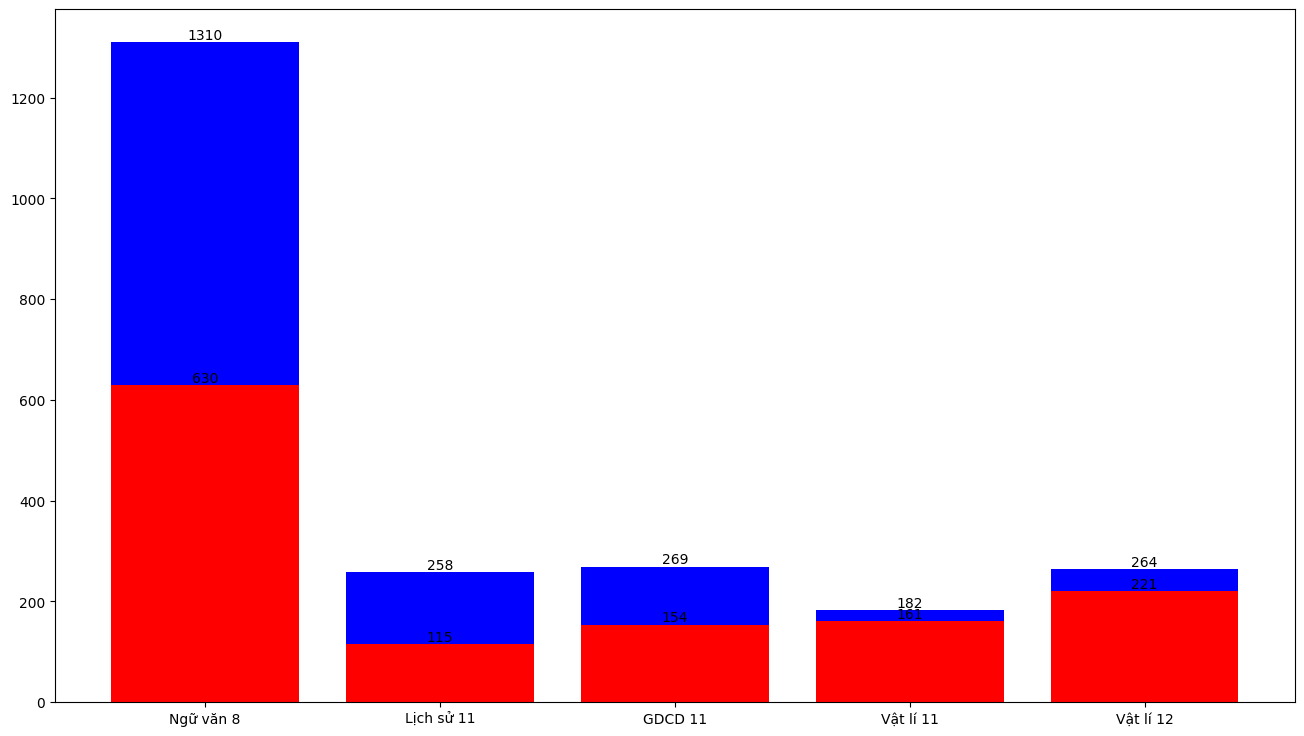

In [19]:
plot_dropped(df)

In [17]:
df['retained'].value_counts()

retained
False    1281
True     1002
Name: count, dtype: int64